In [75]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Accuracy test

In [76]:
import pandas as pd
import json
from collections import Counter
import numpy as np
import pandas as pd
import seaborn as sns
import spacy
import re
import pycountry
import itertools
import sys 
sys.path.append('/home/lhasbini/como_school/como_project4/src/')
from text_processing_functions import *
from constants import *
import LLM_functions
from plot_functions import *
from post_process_functions import *
from accuracy import *
from data import *
from geocoding import *
import copy as cp
import ast

#Package for accuracy 
from sklearn.metrics.pairwise import cosine_similarity

#For plotting
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import cartopy.io.shapereader as shpreader
from cartopy.io import shapereader

In [15]:
# Perform Geocoding over output of chat
# reports_chat = pd.read_csv(DATA_OUT_LLMS+"labelled_reports_response_llm_levels_haz_types_subtypes_impacts.csv", index_col=0)
# reports_chat[['region', 'state', 'city']] = reports_chat[['region', 'state', 'city']].apply(lambda x: x.apply(separate_locs))
# reports_chat[['region', 'state', 'city']] = reports_chat[['region', 'state', 'city']].apply(lambda x: x.apply(remove_startspace))
# reports_chat['region'] = reports_chat.apply(lambda row: [item for item in (row['region'] or []) + (row['state'] or []) if item is not None], axis=1)
# reports_chat = reports_chat.drop('state', axis=1)
# reports_chat = clean_chat_format(reports_chat)
# reports_chat_geo = geocoding_labelled_reports(reports_chat)
# reports_chat_geo.to_csv(DATA_OUT_LLMS+'labelled_reports_response_llm_levels_haz_types_subtypes_impacts_geocoding.csv', encoding='utf-8', index=False)

# print(len(reports_chat_geo)/len(reports_chat), "% of location geocoded")

In [3]:
###### FILE PATHS 
json_file = DATA_IN_JSONS+'filtered_report_types_nat_hazards_summary-header.json'

##### Open and read the JSON file
with open(json_file, 'r') as json_file:
    filtered_reports = json.load(json_file)
filtered_reports = pd.DataFrame(filtered_reports)

In [45]:
# reports_chat = pd.read_csv(DATA_OUT_LLMS+"labelled_reports_response_llm_levels_haz_types_subtypes_impacts.csv", index_col=0)
reports_chat_geo = pd.read_csv(DATA_OUT_LLMS+'labelled_reports_response_llm_levels_haz_types_subtypes_impacts_geocoding.csv')

reports_labelled_laura = pd.read_csv(DATA_LABELLED+"labelled_example_haz-subtype-emdat_chat-format_geocoding_laura.csv")
reports_labelled_luca = pd.read_csv(DATA_LABELLED+"labelled_example_haz-subtype-emdat_chat-format_geocoding_luca.csv", index_col=0)
reports_labelled = pd.concat([reports_labelled_laura, reports_labelled_luca], axis=0)

# Spatial plot - Event centroid

In [40]:
dict_color = {"Flood" : "blue", "Storm" : "purple", "Mass movement" : "brown", "Wave action": "pink"}
dict_marker = {
    "Flood": "o",         # Circle
    "Earthquake": "s",    # Square
    "Mass movement": "^",     # Triangle
    "Storm": "*",         # Diamond
    "Drought": "p",       # Pentagon
    "Wildfire": "v",      # Star
    "Wave action": "h"
}

In [41]:
def centeroidnp(arr):
    length = arr.shape[0]
    sum_x = np.sum(arr[:, 0])
    sum_y = np.sum(arr[:, 1])
    return sum_x/length, sum_y/length

In [42]:
appealCode_test = "MDRDZ011"
tmp_labelled = reports_labelled_laura.loc[reports_labelled_laura.appealCode == appealCode_test]
tmp_chat = reports_chat_geo.loc[reports_chat_geo.appealCode == appealCode_test]

In [37]:
grouping_columns = ["hazardType", "hazardSubtypes", "country", "startYear", "startMonth", "startDay", "endYear", "endMonth", "endDay"] 

#Labelled reports
tmp_labelled[grouping_columns] = tmp_labelled[grouping_columns].fillna('missing')
tmp_labelled_event = tmp_labelled.groupby(grouping_columns)

#Output from chat
tmp_chat[grouping_columns] = tmp_chat[grouping_columns].fillna('missing')
tmp_chat_event = tmp_chat.groupby(grouping_columns)

/tmp/ipykernel_322517/486962333.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp_labelled[grouping_columns] = tmp_labelled[grouping_columns].fillna('missing')
/tmp/ipykernel_322517/486962333.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp_chat[grouping_columns] = tmp_chat[grouping_columns].fillna('missing')


/tmp/ipykernel_224438/3558643876.py:13: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


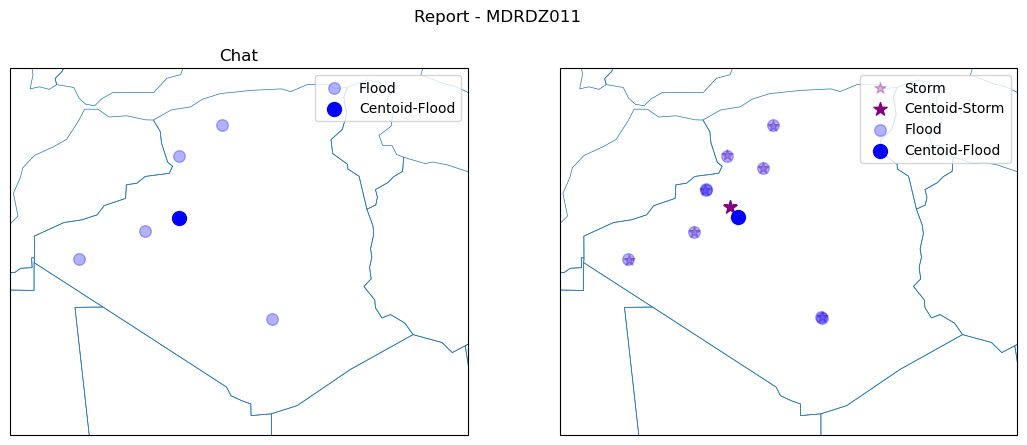

In [103]:
#Plot of the results of labelling 
# keys_labelled = tmp_labelled_event.groups.keys()
# for i in keys_labelled:
#     labelled_event_loop = tmp_labelled_event.get_group(i) 
#     coordinates_labelled = np.column_stack((labelled_event_loop["longitude"], labelled_event_loop["latitude"]))
#     centroid_labelled = centeroidnp(coordinates_labelled)
#     print(centroid_labelled)
import geopandas as gpd
def add_jitter(coords, scale=0.05):
    return coords + np.random.uniform(-scale, scale, size=coords.shape)

f, axes = plt.subplots(1, 2, subplot_kw=dict(projection=ccrs.PlateCarree()),figsize=(13, 5))
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
world.boundary.plot(ax=axes[0], linewidth=0.5)
world.boundary.plot(ax=axes[1], linewidth=0.5)
keys_labelled = tmp_labelled_event.groups.keys()
for i in keys_labelled : 
    # df_all_locs[hazard].plot(ax=axes, color=dict_color[hazard], markersize=50, alpha=0.4)
    marker = dict_marker.get(hazard, "o")  # Default to circle if not in dictionary

    labelled_event_loop = tmp_labelled_event.get_group(i) 
    coordinates_labelled = np.column_stack((labelled_event_loop["longitude"], labelled_event_loop["latitude"]))
    centroid_labelled = centeroidnp(coordinates_labelled)
    
    coordinates_gpd = gpd.GeoDataFrame(labelled_event_loop, geometry=gpd.points_from_xy(labelled_event_loop.longitude, labelled_event_loop.latitude))
    x_values = add_jitter(coordinates_gpd.geometry.x)
    y_values = add_jitter(coordinates_gpd.geometry.y)

    hazard = labelled_event_loop["hazardType"].iloc[0]
    axes[0].scatter(
        x_values, y_values, 
        color=dict_color[hazard], 
        marker=marker, 
        s=70, alpha=0.3, label=hazard
    )
    
    axes[0].scatter(
            centroid_labelled[0], centroid_labelled[1], 
            color=dict_color[hazard], 
            marker=marker, 
            s=100, alpha=1, label="Centoid-"+hazard
        )
axes[0].set_title("Labelling")

#For result with chat
keys_chat = tmp_chat_event.groups.keys()
for i in keys_chat : 
    # df_all_locs[hazard].plot(ax=axes, color=dict_color[hazard], markersize=50, alpha=0.4)
    hazard = chat_event_loop["hazardType"].iloc[0]
    marker = dict_marker.get(hazard, "o")  # Default to circle if not in dictionary

    chat_event_loop = tmp_chat_event.get_group(i) 
    coordinates_chat = np.column_stack((chat_event_loop["longitude"], chat_event_loop["latitude"]))
    centroid_chat = centeroidnp(coordinates_chat)
    
    coordinates_gpd = gpd.GeoDataFrame(chat_event_loop, geometry=gpd.points_from_xy(chat_event_loop.longitude, chat_event_loop.latitude))
    x_values = add_jitter(coordinates_gpd.geometry.x)
    y_values = add_jitter(coordinates_gpd.geometry.y)

    axes[1].scatter(
        x_values, y_values, 
        color=dict_color[hazard], 
        marker=marker, 
        s=70, alpha=0.3, label=hazard
    )
    
    axes[1].scatter(
            centroid_chat[0], centroid_chat[1], 
            color=dict_color[hazard], 
            marker=marker, 
            s=100, alpha=1, label="Centoid-"+hazard
        )
axes[0].set_title("Chat")

# Set the focus on Uganda
for ax in axes : 
    ax.set_xlim([-10, 15])  # Longitude limits
    ax.set_ylim([18, 38])  # Latitude limits
    ax.legend(fontsize=10)
plt.suptitle("Report - "+appealCode_test)
plt.show()

In [43]:
appealCode_test = "MDR55001"
tmp_labelled = reports_labelled_laura.loc[reports_labelled_laura.appealCode == appealCode_test]
tmp_chat = reports_chat_geo.loc[reports_chat_geo.appealCode == appealCode_test]

grouping_columns = ["hazardType", "hazardSubtypes", "country", "startYear", "startMonth", "startDay", "endYear", "endMonth", "endDay"] 

#Labelled reports
tmp_labelled[grouping_columns] = tmp_labelled[grouping_columns].fillna('missing')
tmp_labelled_event = tmp_labelled.groupby(grouping_columns)

#Output from chat
tmp_chat[grouping_columns] = tmp_chat[grouping_columns].fillna('missing')
tmp_chat_event = tmp_chat.groupby(grouping_columns)

/tmp/ipykernel_3616789/1985289930.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp_labelled[grouping_columns] = tmp_labelled[grouping_columns].fillna('missing')
/tmp/ipykernel_3616789/1985289930.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp_chat[grouping_columns] = tmp_chat[grouping_columns].fillna('missing')


In [103]:
tmp_labelled_event.country.unique()

hazardType     hazardSubtypes  country           startYear  startMonth  startDay  endYear  endMonth  endDay 
Flood          coastal flood   Kiribati          missing    missing     missing   missing  missing   missing            [Kiribati]
               missing         Papua New Guinea  missing    missing     missing   missing  missing   missing    [Papua New Guinea]
Mass movement  landslide       Papua New Guinea  missing    missing     missing   missing  missing   missing    [Papua New Guinea]
Storm          storm surge     Kiribati          missing    missing     missing   missing  missing   missing            [Kiribati]
                               Solomon Islands   missing    missing     missing   missing  missing   missing     [Solomon Islands]
                               Tuvalu            missing    missing     missing   missing  missing   missing              [Tuvalu]
               tropical storm  Kiribati          missing    missing     missing   missing  missing   miss

In [102]:
tmp_chat_event.country.unique()

hazardType     hazardSubtypes  country           startYear  startMonth  startDay  endYear  endMonth  endDay
Flood          coastal flood   Kiribati          2015.0     3.0         9.0       2015.0   3.0       9.0               [Kiribati]
               missing         Papua New Guinea  2015.0     3.0         9.0       2015.0   3.0       9.0       [Papua New Guinea]
                               Solomon Islands   2015.0     3.0         9.0       2015.0   3.0       9.0        [Solomon Islands]
Mass movement  landslide       Papua New Guinea  2015.0     3.0         9.0       2015.0   3.0       9.0       [Papua New Guinea]
               missing         Kiribati          2015.0     3.0         9.0       2015.0   3.0       9.0               [Kiribati]
                               Solomon Islands   2015.0     3.0         9.0       2015.0   3.0       9.0        [Solomon Islands]
Storm          storm surge     Kiribati          2015.0     3.0         9.0       2015.0   3.0       9.0        

/tmp/ipykernel_224438/3468070968.py:13: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


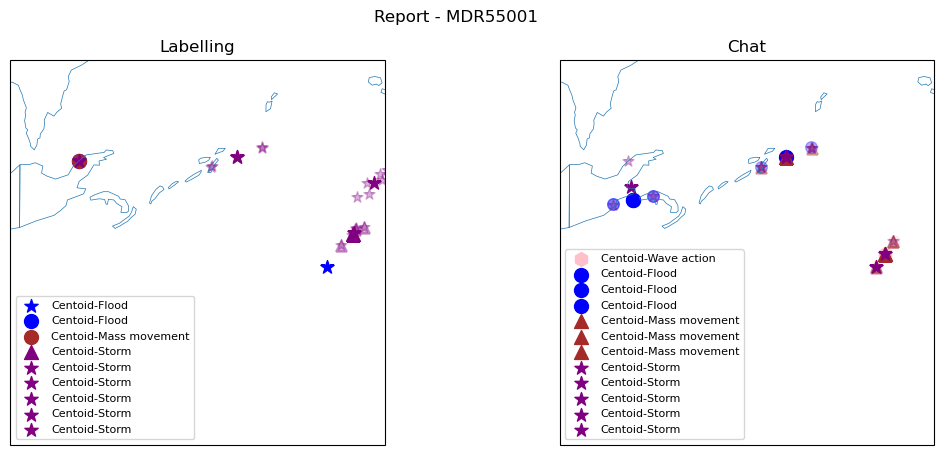

In [123]:
#Plot of the results of labelling 
# keys_labelled = tmp_labelled_event.groups.keys()
# for i in keys_labelled:
#     labelled_event_loop = tmp_labelled_event.get_group(i) 
#     coordinates_labelled = np.column_stack((labelled_event_loop["longitude"], labelled_event_loop["latitude"]))
#     centroid_labelled = centeroidnp(coordinates_labelled)
#     print(centroid_labelled)
import geopandas as gpd
def add_jitter(coords, scale=0.05):
    return coords + np.random.uniform(-scale, scale, size=coords.shape)

f, axes = plt.subplots(1, 2, subplot_kw=dict(projection=ccrs.PlateCarree()),figsize=(13, 5))
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
world.boundary.plot(ax=axes[0], linewidth=0.5)
world.boundary.plot(ax=axes[1], linewidth=0.5)
keys_labelled = tmp_labelled_event.groups.keys()
for i in keys_labelled : 
    # df_all_locs[hazard].plot(ax=axes, color=dict_color[hazard], markersize=50, alpha=0.4)
    marker = dict_marker.get(hazard, "o")  # Default to circle if not in dictionary

    labelled_event_loop = tmp_labelled_event.get_group(i) 
    coordinates_labelled = np.column_stack((labelled_event_loop["longitude"], labelled_event_loop["latitude"]))
    centroid_labelled = centeroidnp(coordinates_labelled)
    
    coordinates_gpd = gpd.GeoDataFrame(labelled_event_loop, geometry=gpd.points_from_xy(labelled_event_loop.longitude, labelled_event_loop.latitude))
    x_values = add_jitter(coordinates_gpd.geometry.x)
    y_values = add_jitter(coordinates_gpd.geometry.y)

    hazard = labelled_event_loop["hazardType"].iloc[0]
    axes[0].scatter(
        x_values, y_values, 
        color=dict_color[hazard], 
        marker=marker, 
        s=70, alpha=0.3#, label=hazard
    )
    
    axes[0].scatter(
            centroid_labelled[0], centroid_labelled[1], 
            color=dict_color[hazard], 
            marker=marker, 
            s=100, alpha=1, label="Centoid-"+hazard
        )
axes[0].set_title("Labelling")

#For result with chat
keys_chat = tmp_chat_event.groups.keys()
for i in keys_chat : 
    # df_all_locs[hazard].plot(ax=axes, color=dict_color[hazard], markersize=50, alpha=0.4)
    hazard = chat_event_loop["hazardType"].iloc[0]
    marker = dict_marker.get(hazard, "o")  # Default to circle if not in dictionary

    chat_event_loop = tmp_chat_event.get_group(i) 
    coordinates_chat = np.column_stack((chat_event_loop["longitude"], chat_event_loop["latitude"]))
    centroid_chat = centeroidnp(coordinates_chat)
    
    coordinates_gpd = gpd.GeoDataFrame(chat_event_loop, geometry=gpd.points_from_xy(chat_event_loop.longitude, chat_event_loop.latitude))
    x_values = add_jitter(coordinates_gpd.geometry.x)
    y_values = add_jitter(coordinates_gpd.geometry.y)

    axes[1].scatter(
        x_values, y_values, 
        color=dict_color[hazard], 
        marker=marker, 
        s=70, alpha=0.3#, label=hazard
    )
    
    axes[1].scatter(
            centroid_chat[0], centroid_chat[1], 
            color=dict_color[hazard], 
            marker=marker, 
            s=100, alpha=1, label="Centoid-"+hazard
        )
axes[1].set_title("Chat")

# Set the focus on Uganda
for ax in axes : 
    ax.set_xlim([140, 179])  # Longitude limits
    ax.set_ylim([20, -20])  # Latitude limits
    ax.legend(fontsize=8, loc='lower left')
plt.suptitle("Report - "+appealCode_test)
plt.show()

# Distances - Several aggregations levels

In [42]:
# Distribution of distance per event 
grouping_event_columns = ["appealCode", "hazardType", "country"]
reports_chat_centroid = centroid_per_event(reports_chat, grouping_columns = grouping_event_columns)
reports_labelled_centroid  = centroid_per_event(reports_labelled, grouping_columns = grouping_event_columns)

reports_chat_centroid = reports_chat_centroid.rename(columns = {"longitude" : "longitude_chat", "latitude" : "latitude_chat"})
reports_centroid = pd.merge(reports_labelled_centroid[grouping_event_columns+["longitude", "latitude"]], 
                            reports_chat_centroid[grouping_event_columns+["longitude_chat", "latitude_chat"]], 
                            on=grouping_event_columns, how="outer")
reports_centroid = compute_distance(reports_centroid)

19


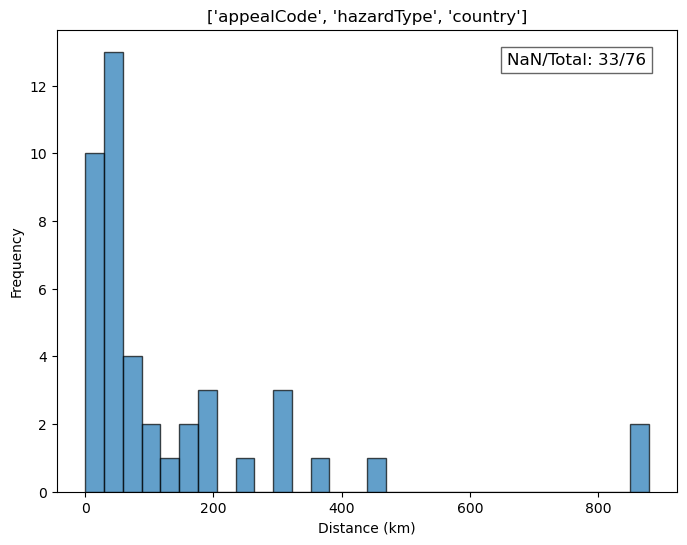

In [43]:
fig = plt.figure(figsize=(8, 6))
    
# Histogram of distances
reports_centroid['distance_km'].dropna().plot(kind='hist', bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Distance (km)')
plt.ylabel('Frequency')
plt.title(grouping_event_columns)

# Count NaN values and display as text
nan_count = reports_centroid['distance_km'].isna().sum()
nan_labelled = reports_centroid['longitude'].isna().sum()
print(nan_labelled)
plt.text(0.95, 0.95, f'NaN/Total: {nan_count}/{len(reports_centroid)}', transform=plt.gca().transAxes, 
         fontsize=12, verticalalignment='top', horizontalalignment='right', 
         bbox=dict(facecolor='white', alpha=0.6))

plt.show()
grouping_str = "_".join(grouping_event_columns) if isinstance(grouping_event_columns, list) else grouping_event_columns
fig.savefig(f"{DATA_FIGURE}distances_event_{grouping_str}.png", transparent=True, bbox_inches='tight')

In [36]:
grouping_event_columns = ["appealCode", "hazardType", "hazardSubtypes", "country"]
reports_chat_centroid = centroid_per_event(reports_chat, grouping_columns = grouping_event_columns)
reports_labelled_centroid  = centroid_per_event(reports_labelled, grouping_columns = grouping_event_columns)

reports_chat_centroid = reports_chat_centroid.rename(columns = {"longitude" : "longitude_chat", "latitude" : "latitude_chat"})
reports_centroid = pd.merge(reports_labelled_centroid[grouping_event_columns+["longitude", "latitude"]], 
                            reports_chat_centroid[grouping_event_columns+["longitude_chat", "latitude_chat"]], 
                            on=grouping_event_columns, how="outer")
reports_centroid = compute_distance(reports_centroid)

19


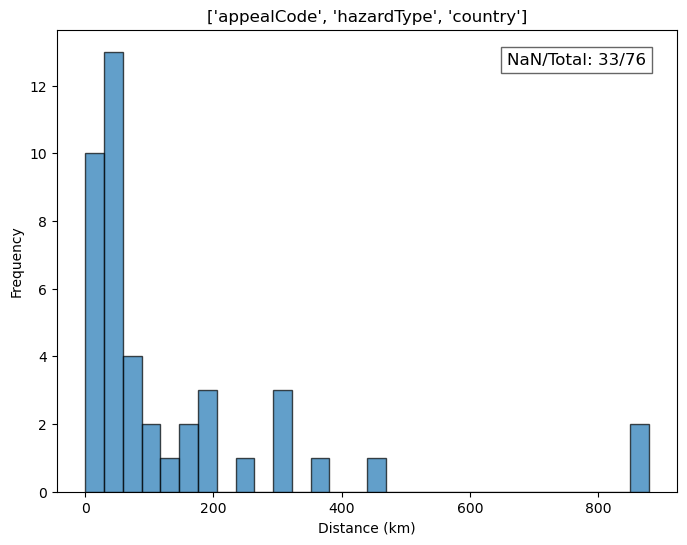

In [44]:
fig = plt.figure(figsize=(8, 6))
    
# Histogram of distances
reports_centroid['distance_km'].dropna().plot(kind='hist', bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Distance (km)')
plt.ylabel('Frequency')
plt.title(grouping_event_columns)

# Count NaN values and display as text
nan_count = reports_centroid['distance_km'].isna().sum()
nan_labelled = reports_centroid['longitude'].isna().sum()
print(nan_labelled)
plt.text(0.95, 0.95, f'NaN/Total: {nan_count}/{len(reports_centroid)}', transform=plt.gca().transAxes, 
         fontsize=12, verticalalignment='top', horizontalalignment='right', 
         bbox=dict(facecolor='white', alpha=0.6))

plt.show()
grouping_str = "_".join(grouping_event_columns) if isinstance(grouping_event_columns, list) else grouping_event_columns
fig.savefig(f"{DATA_FIGURE}distances_event_{grouping_str}.png", transparent=True, bbox_inches='tight')

In [38]:
grouping_event_columns = ["appealCode", "country"]
reports_chat_centroid = centroid_per_event(reports_chat, grouping_columns = grouping_event_columns)
reports_labelled_centroid  = centroid_per_event(reports_labelled, grouping_columns = grouping_event_columns)

reports_chat_centroid = reports_chat_centroid.rename(columns = {"longitude" : "longitude_chat", "latitude" : "latitude_chat"})
reports_centroid = pd.merge(reports_labelled_centroid[grouping_event_columns+["longitude", "latitude"]], 
                            reports_chat_centroid[grouping_event_columns+["longitude_chat", "latitude_chat"]], 
                            on=grouping_event_columns, how="outer")
reports_centroid = compute_distance(reports_centroid)

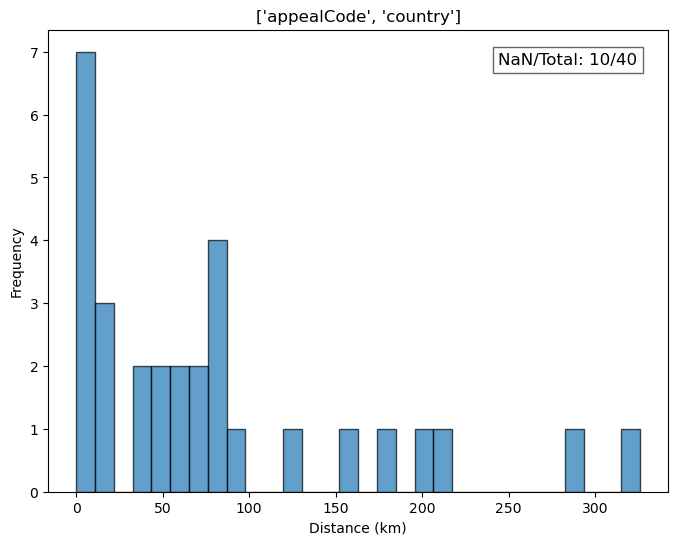

In [39]:
fig = plt.figure(figsize=(8, 6))
    
# Histogram of distances
reports_centroid['distance_km'].dropna().plot(kind='hist', bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Distance (km)')
plt.ylabel('Frequency')
plt.title(grouping_event_columns)

# Count NaN values and display as text
nan_count = reports_centroid['distance_km'].isna().sum()
plt.text(0.95, 0.95, f'NaN/Total: {nan_count}/{len(reports_centroid)}', transform=plt.gca().transAxes, 
         fontsize=12, verticalalignment='top', horizontalalignment='right', 
         bbox=dict(facecolor='white', alpha=0.6))

plt.show()
grouping_str = "_".join(grouping_event_columns) if isinstance(grouping_event_columns, list) else grouping_event_columns
fig.savefig(f"{DATA_FIGURE}distances_event_{grouping_str}.png", transparent=True, bbox_inches='tight')

In [40]:
grouping_event_columns = ["appealCode"]
reports_chat_centroid = centroid_per_event(reports_chat, grouping_columns = grouping_event_columns)
reports_labelled_centroid  = centroid_per_event(reports_labelled, grouping_columns = grouping_event_columns)

reports_chat_centroid = reports_chat_centroid.rename(columns = {"longitude" : "longitude_chat", "latitude" : "latitude_chat"})
reports_centroid = pd.merge(reports_labelled_centroid[grouping_event_columns+["longitude", "latitude"]], 
                            reports_chat_centroid[grouping_event_columns+["longitude_chat", "latitude_chat"]], 
                            on=grouping_event_columns, how="outer")
reports_centroid = compute_distance(reports_centroid)

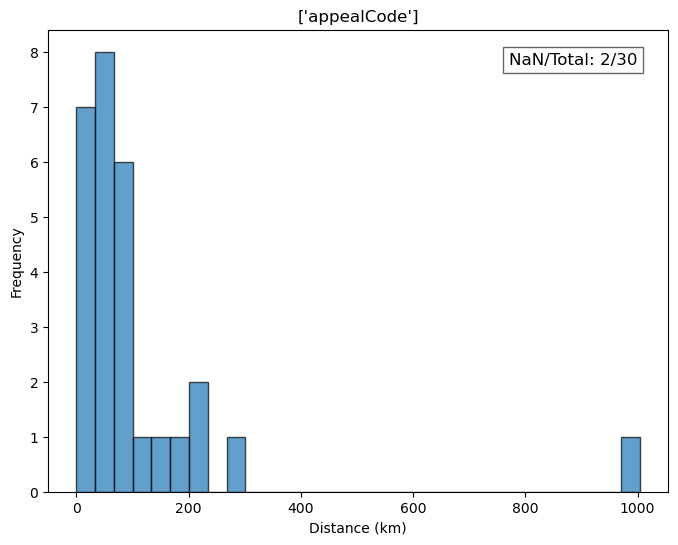

In [41]:
fig = plt.figure(figsize=(8, 6))
    
# Histogram of distances
reports_centroid['distance_km'].dropna().plot(kind='hist', bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Distance (km)')
plt.ylabel('Frequency')
plt.title(grouping_event_columns)

# Count NaN values and display as text
nan_count = reports_centroid['distance_km'].isna().sum()
plt.text(0.95, 0.95, f'NaN/Total: {nan_count}/{len(reports_centroid)}', transform=plt.gca().transAxes, 
         fontsize=12, verticalalignment='top', horizontalalignment='right', 
         bbox=dict(facecolor='white', alpha=0.6))

plt.show()
grouping_str = "_".join(grouping_event_columns) if isinstance(grouping_event_columns, list) else grouping_event_columns
fig.savefig(f"{DATA_FIGURE}distances_event_{grouping_str}.png", transparent=True, bbox_inches='tight')

# Shared events

In [13]:
dict_grouping = {"Code_Type_Subtype_Country" : ["appealCode", "hazardType", "hazardSubtypes", "country"], 
                 "Code_Type_Country" : ["appealCode", "hazardType", "country"], 
                 "Code_Country" : ["appealCode", "country"], 
                 "Code" : ["appealCode"]}
dict_grouping_count = pd.DataFrame(columns = dict_grouping.keys())

for group in dict_grouping.keys() :
    grouping_columns = dict_grouping[group]

    #Perform grouping 
    reports_chat_centroid = centroid_per_event(reports_chat, grouping_columns = grouping_columns)
    reports_labelled_centroid  = centroid_per_event(reports_labelled, grouping_columns = grouping_columns)
    
    reports_chat_centroid = reports_chat_centroid.rename(columns = {"longitude" : "longitude_chat", "latitude" : "latitude_chat"})
    reports_centroid = pd.merge(reports_labelled_centroid[grouping_columns+["longitude", "latitude"]], 
                                reports_chat_centroid[grouping_columns+["longitude_chat", "latitude_chat"]], 
                                on=grouping_columns, how="outer")
    reports_centroid = compute_distance(reports_centroid)

    #Values to stack
    total_count = len(reports_centroid)
    nan_count = reports_centroid['distance_km'].isna().sum()
    nan_labelled = reports_centroid['longitude'].isna().sum()
    values = [total_count-nan_count, nan_labelled, nan_count-nan_labelled]
    dict_grouping_count[group] = values

values_description = ["Common", "Chat_only", "Labelling_only"]
dict_grouping_count.index = values_description

In [14]:
dict_grouping_count

,Code_Type_Subtype_Country,Code_Type_Country,Code_Country,Code
Common,45,43,30,28
Chat_only,34,19,2,1
Labelling_only,19,14,8,1


(array([0, 1, 2, 3]),
 [Text(0, 0, 'Code_Type_Subtype_Country'),
  Text(1, 0, 'Code_Type_Country'),
  Text(2, 0, 'Code_Country'),
  Text(3, 0, 'Code')])

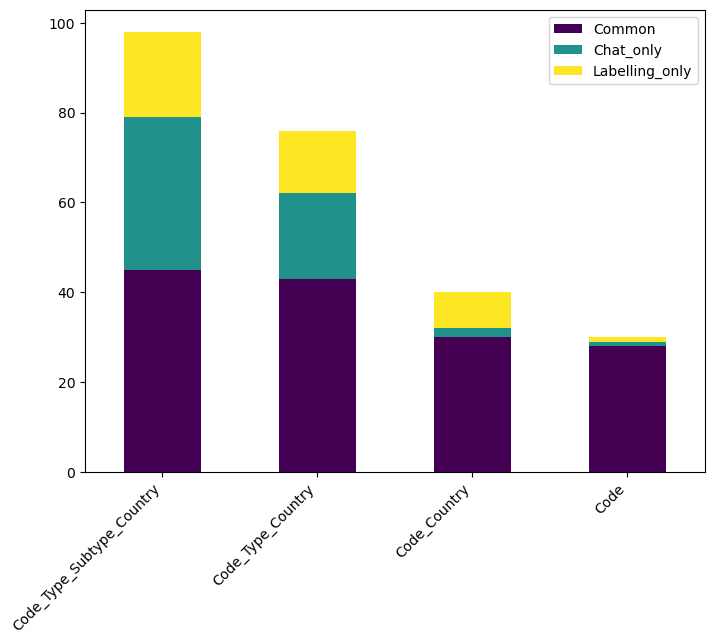

In [17]:
dict_grouping_count.T.plot(kind="bar", stacked=True, figsize=(8, 6), colormap="viridis")
plt.xticks(rotation=45, ha="right")

# Compute accuracy

In [49]:
accuracy_columns = ["hazardType", "hazardSubtypes", "country", "region", "state", "city", "startYear", "startMonth", "startDay", "endYear", "endMonth", "endDay", "hazardName"]
grouping_columns = ["hazardType", "country", "startYear", "startMonth", "startDay", "endYear", "endMonth", "endDay"]
accuracy = calculate_precision_per_report(reports_chat_geo, reports_labelled, accuracy_columns, grouping_columns=grouping_columns)

In [50]:
accuracy[grouping_columns]

,hazardType,country,startYear,startMonth,startDay,endYear,endMonth,endDay
0,0.829738,0.882252,0.870711,0.762726,0.49181,0.433333,0.342815,0.169245


In [51]:
accuracy.loc[:, ~accuracy.columns.isin(grouping_columns)]

,hazardSubtypes,region,state,city,hazardName
0,0.0,0.05873,0.274924,0.070202,0.147222


In [28]:
accuracy_precision_recall_f1 = calculate_recall_precision_f1_per_report(reports_chat, reports_labelled, accuracy_columns, grouping_columns=grouping_columns)

In [37]:
accuracy_precision_recall_f1.loc[grouping_columns, :]

,recall,precision,f1_score
hazardType,0.757964,0.723093,0.684826
country,0.828161,0.794671,0.755038
startYear,0.723892,0.701149,0.657337
startMonth,0.627833,0.643678,0.586956
startDay,0.398768,0.448276,0.390788
endYear,0.371921,0.316092,0.313027
endMonth,0.292282,0.238506,0.243295
endDay,0.177340,0.146552,0.145594


In [36]:
accuracy_precision_recall_f1.loc[~accuracy_precision_recall_f1.index.isin(grouping_columns), :]

,recall,precision,f1_score
hazardSubtypes,0.536207,0.432759,0.463465
region,0.471522,0.548463,0.484135
city,0.302752,0.294026,0.291064
hazardName,0.043103,0.068966,0.048276


In [ ]:
fig = plt.figure(figsize=(10, 5))  # Adjust figure size if needed
bars = plt.bar(accuracy.columns, accuracy)

# Rotate x-axis labels
plt.xticks(rotation=45, ha="right")  # Rotate by 45° and align to the right

# Add values above each bar with two-colored text
for i, bar in enumerate(bars):
    height = bar.get_height()
    
    # Get count values for the current x_tick
    count_labelled = count_event_labelled[x_ticks[i]]
    count_chat = count_event_chat[x_ticks[i]]
    
    # Combine both numbers into a single string with different colors
    text = f"{count_labelled} / {count_chat}"
    
    # Add the text at the top of the bars
    plt.text(bar.get_x() + bar.get_width()/2, height, text,
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# Add legend for colors
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='w',label='Labelled/Chat'),
]
plt.legend(handles=legend_elements, fontsize=10, loc="upper right")

plt.ylabel("Accuracy")
plt.show()
# fig.savefig(DATA_FIGURE+"accuracy_hazardType_labelled_examples", transparent=True, bbox_inches='tight')

In [19]:
accuracy_per_hazard = calculate_precision_per_hazardType(reports_chat, reports_labelled, accuracy_columns)

In [20]:
df_list = []

for key, df in accuracy_per_hazard.items():
    # Add a new column 'HAZARD' with the key value
    df['HAZARD'] = key
    # Append the dataframe to the list
    df_list.append(df)

# Concatenate all DataFrames in the list into a single DataFrame
combined_df = pd.concat(df_list, ignore_index=True)

In [21]:
combined_df

,hazardType,hazardSubtypes,country,region,city,startYear,startMonth,startDay,endYear,endMonth,endDay,hazardName,HAZARD
0,0.666667,0.666667,0.333333,0.900000,0.666667,1.0000,0.500000,0.500000,1.000000,0.500000,0.500,1.000000,Drought
1,1.000000,0.707107,1.000000,0.636364,0.045455,0.5000,0.500000,0.500000,1.000000,1.000000,1.000,1.000000,Wildfire
2,1.000000,1.000000,1.000000,0.625000,1.000000,1.0000,0.500000,0.333333,1.000000,2.000000,2.000,1.000000,Earthquake
3,0.500000,0.441421,0.457735,4.000000,3.650000,1.0000,1.200000,1.200000,1.000000,1.200000,1.200,1.000000,Mass movement
4,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Volcanic activity
5,1.000000,0.385355,0.940825,1.102020,2.113535,0.9750,0.941667,0.916667,0.941667,0.941667,0.950,0.975000,Flood
6,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Wave action
7,0.600000,0.341421,0.600000,1.666667,3.375000,1.0000,1.000000,1.000000,1.000000,1.000000,1.000,1.000000,Extreme temperature
8,0.666667,0.500000,0.597018,2.188358,5.328125,0.9375,0.875000,0.791667,1.000000,1.000000,0.875,0.697917,Storm


In [22]:
#Compute the number of event for hazardType
#One event is a unique combinaison of variables
#["appealCode", "hazardType", "hazardSubtypes", "country", "startYear", "startMonth", "startDay", "endYear", "endMonth", "endDay"] 
unique_event_columns = ["appealCode", "hazardType", "country", "startYear", "startMonth", "startDay", "endYear", "endMonth", "endDay"]
count_event_labelled = {}
count_event_chat = {}

reports_labelled_event = reports_labelled.groupby(unique_event_columns)
count_event_labelled["All"] = len(reports_labelled_event.groups.keys())
reports_chat_event = reports_chat.groupby(unique_event_columns)
count_event_chat["All"] = len(reports_chat_event.groups.keys())

#Loop per event
for hazard in maintype_to_subytpe_emdat.keys() :
    reports_labelled_haz = reports_labelled.loc[reports_labelled.hazardType == hazard].groupby(unique_event_columns)
    count_event_labelled[hazard] = len(reports_labelled_haz.groups.keys())
    
    reports_chat_haz = reports_chat.loc[reports_chat.hazardType == hazard].groupby(unique_event_columns)
    count_event_chat[hazard] = len(reports_chat_haz.groups.keys())

for subhazard in ast.literal_eval(hazard_all_subtype_emdat) :
    reports_labelled_haz = reports_labelled.loc[reports_labelled.hazardSubtypes == subhazard].groupby(unique_event_columns)
    count_event_labelled[subhazard] = len(reports_labelled_haz.groups.keys())
    
    reports_chat_haz = reports_chat.loc[reports_chat.hazardSubtypes == subhazard].groupby(unique_event_columns)
    count_event_chat[subhazard] = len(reports_chat_haz.groups.keys())

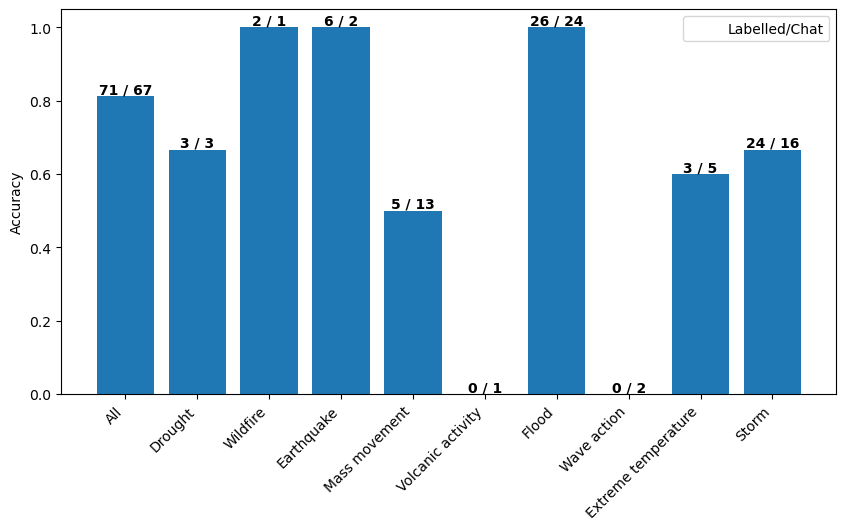

In [32]:
x_ticks = ["All"] + combined_df["HAZARD"].to_list()
y_values = [float(accuracy.hazardType)]+combined_df.hazardType.to_list()

fig = plt.figure(figsize=(10, 5))  # Adjust figure size if needed
bars = plt.bar(x_ticks, y_values)

# Rotate x-axis labels
plt.xticks(rotation=45, ha="right")  # Rotate by 45° and align to the right

# Add values above each bar with two-colored text
for i, bar in enumerate(bars):
    height = bar.get_height()
    
    # Get count values for the current x_tick
    count_labelled = count_event_labelled[x_ticks[i]]
    count_chat = count_event_chat[x_ticks[i]]
    
    # Combine both numbers into a single string with different colors
    text = f"{count_labelled} / {count_chat}"
    
    # Add the text at the top of the bars
    plt.text(bar.get_x() + bar.get_width()/2, height, text,
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# Add legend for colors
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='w',label='Labelled/Chat'),
]
plt.legend(handles=legend_elements, fontsize=10, loc="upper right")

plt.ylabel("Accuracy")
plt.show()
fig.savefig(DATA_FIGURE+"accuracy_hazardType_labelled_examples", transparent=True, bbox_inches='tight')

In [24]:
accuracy_per_hazardSubtype = calculate_precision_per_hazardSubtypes(reports_chat, reports_labelled, accuracy_columns)
df_list = []

for key, df in accuracy_per_hazardSubtype.items():
    # Add a new column 'HAZARD' with the key value
    df['HAZARD'] = key
    # Append the dataframe to the list
    df_list.append(df)

# Concatenate all DataFrames in the list into a single DataFrame
combined_df_Subtypes = pd.concat(df_list, ignore_index=True)

In [25]:
# combined_df_Subtypes

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

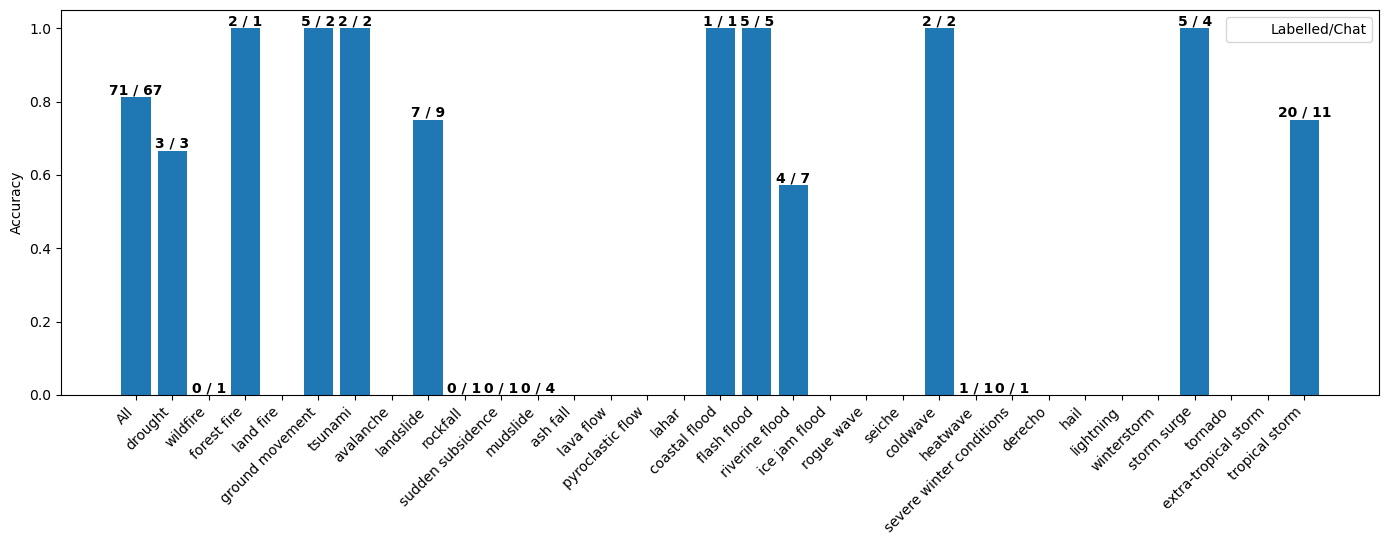

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

In [33]:
x_ticks = ["All"] + combined_df_Subtypes["HAZARD"].to_list()
y_values = [float(accuracy.hazardType)]+combined_df_Subtypes.hazardSubtypes.to_list()

fig = plt.figure(figsize=(17, 5))  # Adjust figure size if needed
bars = plt.bar(x_ticks, y_values)

# Rotate x-axis labels
plt.xticks(rotation=45, ha="right")  # Rotate by 45° and align to the right

# Add values above each bar with two-colored text
for i, bar in enumerate(bars):
    height = bar.get_height()
    
    # Get count values for the current x_tick
    count_labelled = count_event_labelled[x_ticks[i]]
    count_chat = count_event_chat[x_ticks[i]]
    
    # Combine both numbers into a single string with different colors
    text = f"{count_labelled} / {count_chat}"
    
    # Add the text at the top of the bars
    plt.text(bar.get_x() + bar.get_width()/2, height, text,
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# Add legend for colors
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='w',label='Labelled/Chat'),
]
plt.legend(handles=legend_elements, fontsize=10, loc="upper right")

plt.ylabel("Accuracy")
plt.show()
fig.savefig(DATA_FIGURE+"accuracy_hazardSubType_labelled_examples", transparent=True, bbox_inches='tight')

In [4]:
path_test_csv = '/scratchx/lhasbini/como_school/'

######   Predicted with hazard detected by regex
#labelled_chat_output = pd.read_csv(path_test_csv+'11_label_v2_predict_llmgpt-4o-mini.csv')
#labelled_chat_output = pd.read_csv(path_test_csv+'10labelled_response_llm_levels_1.csv')
labelled_regex_output = pd.read_csv(path_test_csv+'10labelled_response_llm_levels_subtypes_1.csv')
# labelled_chat_output = labelled_chat_output.loc[:,['Hazard', 'Country', 'Location', 'Start_Date', 'End_Date', 'appealCode']]
# labelled_chat_output = labelled_chat_output.dropna(subset=['Hazard']).copy()

# #Convert country code 
# labelled_chat_output['Country'] = labelled_chat_output['Country'].str.extract(r"\['(.*?)'\]")
# labelled_chat_output['Country'] = [country_name_to_iso3(cntr) for cntr in labelled_chat_output['Country']]

###### Predicted with hazard detected by CHAT
labelled_chat_output = pd.read_csv(path_test_csv+'10labelled_response_llm_levels_haz_types_subtypes_1.csv')

#####    Labelled
labelled_example = pd.read_csv(path_test_csv+'labelled_example_haz-subtype-emdat.csv')
labelled_example = labelled_example.rename(columns={'Locations': 'Location'})

In [5]:
#Add the em-dat main type 
# labelled_chat_output['Hazard_main'] = labbelled_chat_output['Hazard'].map(hazard_category_map)
labelled_example = labelled_example.rename(columns={"Hazard" : "Hazard_subtype"})
labelled_example['Hazard'] = labelled_example['Hazard_subtype'].map(hazard_category_map)

# Accuracy - Impact 

In [70]:
# reports_chat = pd.read_csv(DATA_OUT_LLMS+"labelled_reports_response_llm_levels_haz_types_subtypes_impacts.csv", index_col=0)
reports_chat_impact = pd.read_csv(DATA_OUT_LLMS+'llm_response_impact-based_quant_test.csv')
# reports_labelled_impact_laura = pd.read_csv(DATA_LABELLED+"labelled_example_haz-subtype-emdat_chat-format_geocoding_laura.csv")
reports_labelled_impact_luca = pd.read_csv(DATA_LABELLED+"labelled_reports_impact_luca.csv")
reports_labelled = reports_labelled_impact_luca#pd.concat([reports_labelled_laura, reports_labelled_luca], axis=0)

In [55]:
from src.geocoding import *
from src.post_process_functions import *
# df_labelled_impact = convert_labelled_chat_format(reports_labelled)
df_labelled_impact_geo = geocoding_reports_location(reports_labelled)

In [71]:
reports_chat_impact = reports_chat_impact.rename({"impactType" : "impactSubtypes"}, axis=1)

In [72]:
reports_chat_impact.head()

,Unnamed: 0,appealCode,location,reportDate,disasterType,impactSubtypes,impactValue,impactDate,hazards,impactAnnotation
0,0,MDRBD015,NaN,2016-03-04,Cyclone,Affected People,2600000.0,NaN,['tropical storm'],['The cumulative effect of the floods coming a...
1,1,MDRBD015,['southern Bangladesh'],2016-03-04,Cyclone,Homeless People,218665.0,NaN,"['tropical storm', 'flood']",['The cumulative effect of the floods coming a...
2,2,MDRBD015,NaN,2016-03-04,Cyclone,WASH infrastructure,NaN,NaN,"['tropical storm', 'flood']",['...provided from its Disaster Preparedness s...
3,3,MDRBD015,['southern Bangladesh'],2016-03-04,Cyclone,Residential Buildings,0.0,NaN,"['tropical storm', 'flood']","['Due to the impact of the cyclonic storm, hea..."
4,4,MDRBD022,['Bangladesh'],2020-12-05,['Flood'],Affected People,7600000.0,2019/07,['riverine flood'],['more than 7.6 million people were affected i...


In [77]:
accuracy_columns = ["impactSubtypes"]
accuracy_impact = calculate_accuracy_impact_per_report(reports_chat_impact, reports_labelled, accuracy_columns)

In [82]:
reports_chat_impact.appealCode.unique()

array(['MDRBD015', 'MDRBD022', 'MDRBZ006', 'MDRCN006', 'MDRIQ014',
       'MDRKE058', 'MDRSD034'], dtype=object)

In [78]:
accuracy_impact

,impactSubtypes
0,0.374133


In [79]:
reports_labelled.loc[reports_labelled.appealCode=="MDRBD015"]

,reportDate,impactSubtypes,impactValue,impactAnnotation,country,location,locationAnnotation,startYear,startMonth,startDay,endYear,endMonth,endDay,hazardType,appealCode
0,2015-09-16,Residential Buildings,NaN,['The Government district level ‘D-form’ data ...,Bangladesh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"['Flood', 'Storm']",MDRBD015
1,2015-09-16,IT and Communication Infrastructure,NaN,['The Government district level ‘D-form’ data ...,Bangladesh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"['Flood', 'Storm']",MDRBD015
2,2015-09-16,Affected People,2600000.0,['The cumulative effect of the floods coming a...,Bangladesh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"['Flood', 'Storm']",MDRBD015
3,2015-09-16,Residential Buildings,NaN,['An aerial survey was conducted on 30 August ...,Bangladesh,['northern districts'],['An aerial survey was conducted on 30 August ...,NaN,NaN,NaN,NaN,NaN,NaN,"['Flood', 'Storm']",MDRBD015
4,2015-09-16,Displaced People,NaN,['An aerial survey was conducted on 30 August ...,Bangladesh,['northern districts'],['An aerial survey was conducted on 30 August ...,NaN,NaN,NaN,NaN,NaN,NaN,"['Flood', 'Storm']",MDRBD015


In [80]:
reports_chat_impact.loc[reports_chat_impact.appealCode=="MDRBD015"]

,Unnamed: 0,appealCode,location,reportDate,disasterType,impactSubtypes,impactValue,impactDate,hazards,impactAnnotation
0,0,MDRBD015,NaN,2016-03-04,Cyclone,Affected People,2600000.0,NaN,['tropical storm'],['The cumulative effect of the floods coming a...
1,1,MDRBD015,['southern Bangladesh'],2016-03-04,Cyclone,Homeless People,218665.0,NaN,"['tropical storm', 'flood']",['The cumulative effect of the floods coming a...
2,2,MDRBD015,NaN,2016-03-04,Cyclone,WASH infrastructure,NaN,NaN,"['tropical storm', 'flood']",['...provided from its Disaster Preparedness s...
3,3,MDRBD015,['southern Bangladesh'],2016-03-04,Cyclone,Residential Buildings,0.0,NaN,"['tropical storm', 'flood']","['Due to the impact of the cyclonic storm, hea..."


In [83]:
reports_labelled.loc[reports_labelled.appealCode=="MDRBD022"]

,reportDate,impactSubtypes,impactValue,impactAnnotation,country,location,locationAnnotation,startYear,startMonth,startDay,endYear,endMonth,endDay,hazardType,appealCode
5,2020-12-05,Affected People,7600000.0,['According to the National Needs Assessment W...,Bangladesh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,['Flood'],MDRBD022
6,2020-12-05,Displaced People,300000.0,['According to the National Needs Assessment W...,Bangladesh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,['Flood'],MDRBD022
7,2020-12-05,Residential Buildings,600000.0,['According to the National Needs Assessment W...,Bangladesh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,['Flood'],MDRBD022
8,2020-12-05,Human Deaths,114.0,['According to the National Needs Assessment W...,Bangladesh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,['Flood'],MDRBD022
9,2020-12-05,Transportation Infrastructure,NaN,['It was also reported that embankments were d...,Bangladesh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,['Flood'],MDRBD022
10,2020-12-05,Affected People,40000.0,"['Due to this second spell of flood, around 40...",Bangladesh,NaN,NaN,2019.0,10.0,NaN,NaN,NaN,NaN,['Flood'],MDRBD022
11,2020-12-05,Healthcare Infrastructure,NaN,['While more than half of the country experien...,Bangladesh,NaN,NaN,2019.0,6.0,NaN,2019.0,10.0,NaN,['Flood'],MDRBD022
12,2020-12-05,Displaced People,2400000.0,['Following the great danger signal and evacua...,Bangladesh,['coastal districts'],['Following the great danger signal and evacua...,NaN,NaN,NaN,NaN,NaN,NaN,['Storm'],MDRBD022
13,2020-12-05,Affected People,2600000.0,['Approximately 2.6 million people were affect...,Bangladesh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,['Storm'],MDRBD022
14,2020-12-05,Residential Buildings,205368.0,['Approximately 2.6 million people were affect...,Bangladesh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,['Storm'],MDRBD022


In [87]:
reports_chat_impact.loc[reports_chat_impact.appealCode=="MDRBD022"]

,Unnamed: 0,appealCode,location,reportDate,disasterType,impactSubtypes,impactValue,impactDate,hazards,impactAnnotation
4,4,MDRBD022,['Bangladesh'],2020-12-05,['Flood'],Affected People,7600000.0,2019/07,['riverine flood'],['more than 7.6 million people were affected i...
5,5,MDRBD022,['Bangladesh'],2020-12-05,['Flood'],Displaced People,300000.0,2019/07,['riverine flood'],"['over 300,000 people displaced']"
6,6,MDRBD022,NaN,2020-12-05,['Flood'],Homeless People,300000.0,2019/07,['riverine flood'],"['over 300,000 people displaced']"
7,7,MDRBD022,NaN,2020-12-05,['Flood'],Human Deaths,114.0,2019/07/28,['riverine flood'],['According to the National Needs Assessment W...
8,8,MDRBD022,['19 coastal districts'],2020-12-05,['Flood'],WASH infrastructure,40894.0,2020/05/20,['tropical storm'],"['40,894 latrines were damaged in the 19 affec..."
9,9,MDRBD022,NaN,2020-12-05,['Flood'],Healthcare Infrastructure,266.0,NaN,['dengue'],"['The Institute of Epidemiology, Disease Contr..."
10,10,MDRBD022,NaN,2020-12-05,['Flood'],Residential Buildings,600000.0,NaN,['flood'],"['approximately 600,000 houses damaged']"
11,11,MDRBD022,['Bangladesh'],2020-12-05,['Flood'],Informal Settlements,300000.0,2019/07,['riverine flood'],"['over 300,000 people displaced']"
